In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_optimal_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import print_metrics

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing"
LOCATION = "jablje"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [4]:
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
for year in range(1993, 2024) if year not in [2017]]

In [5]:
jablje_temperatures, jablje_eto, jablje_rain = get_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [9]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    #ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/notebooks/exploration/E:/aquacrop/testing
Running AquaCrop simulation with project file: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/notebooks/exploration/E:/aquacrop/testing/LIST/PROJECT.PRM
Detected platform: darwin (arm64)
Looking for executable at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/.venv/lib/python3.14/site-packages/model/macOS/aquacrop
Using AquaCrop executable: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/notebooks/exploration/E:/aquacrop/testing/aquacrop
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,1180.9,760.6,1135.1,355.97,0.0,895.2,...,40.2,4.937,6.496,1.51,0.0,0.0,31,12,1993,PROJECT.PRM
1,2,1,1,1994,1265.4,745.2,1207.5,357.58,0.0,1023.1,...,46.0,7.895,10.388,1.97,0.0,0.0,31,12,1994,PROJECT.PRM
2,3,1,1,1995,1436.3,695.6,1017.1,359.53,0.0,1077.6,...,46.3,6.806,8.956,1.87,0.0,0.0,31,12,1995,PROJECT.PRM
3,4,1,1,1996,1439.8,644.8,992.3,361.26,0.0,1078.5,...,40.1,5.531,7.278,1.67,0.0,0.0,31,12,1996,PROJECT.PRM
4,5,1,1,1997,1144.1,725.2,1104.4,362.43,0.0,919.2,...,45.6,8.074,10.624,2.11,0.0,0.0,31,12,1997,PROJECT.PRM
5,6,1,1,1998,1347.8,709.7,1200.0,365.14,0.0,1032.6,...,41.4,6.321,8.317,1.94,0.0,0.0,31,12,1998,PROJECT.PRM
6,7,1,1,1999,1390.5,679.8,1238.6,366.96,0.0,1112.5,...,46.2,8.109,10.670,2.12,0.0,0.0,31,12,1999,PROJECT.PRM
7,8,1,1,2000,1439.3,747.8,1231.1,368.25,0.0,1126.5,...,37.7,6.330,8.329,1.63,0.0,0.0,31,12,2000,PROJECT.PRM
8,9,1,1,2001,1169.9,699.8,1163.8,369.65,0.0,934.4,...,45.0,6.963,9.162,1.89,0.0,0.0,31,12,2001,PROJECT.PRM
9,10,1,1,2002,1176.9,689.4,1176.5,371.87,0.0,980.7,...,46.1,8.252,10.858,2.25,0.0,0.0,31,12,2002,PROJECT.PRM


In [13]:
get_yield(LOCATION, "grain", "A", "N3")

,year,yield
0,1993,7.830
1,1994,10.422
2,1995,12.013
3,1996,8.270
4,1997,10.369
5,1998,8.889
6,1999,9.760
7,2000,10.134
8,2001,6.792
9,2002,12.080


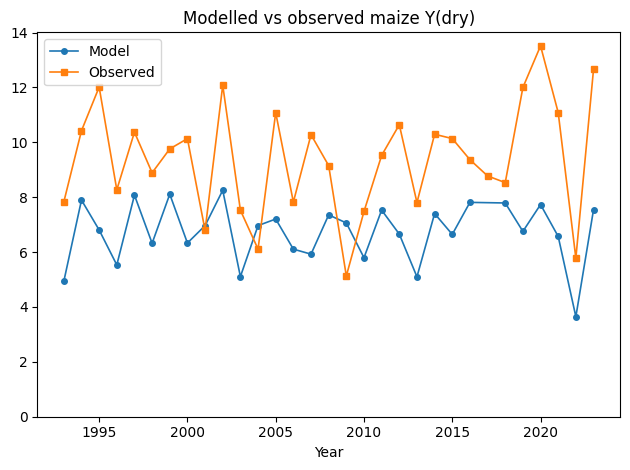

In [14]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

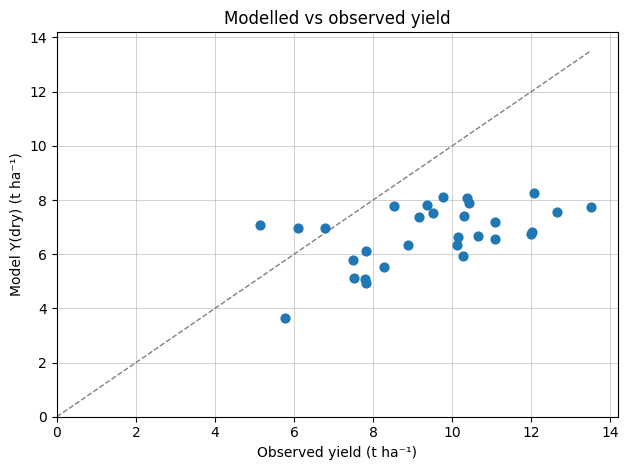

In [15]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [16]:
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)", "Grain")

=== Grain ===
  RMSE:       3.2099
  R2:         -1.4471
  NSE:        -1.4471
  KGE:        0.2646
  mKGE:       0.3786
  KGE_r:      0.5149
  KGE_beta:   0.7148
  KGE_alpha:  0.5265
  mKGE_alpha: 0.7365


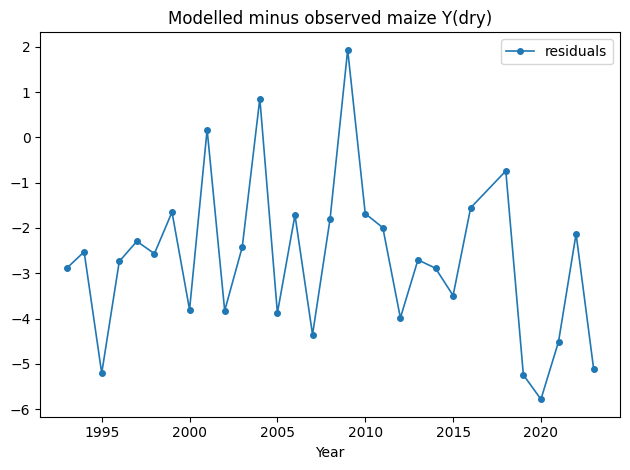

In [17]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

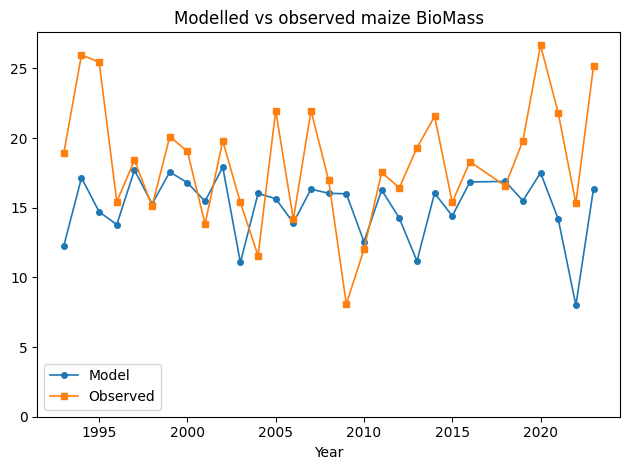

In [18]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass")

=== Biomass ===
  RMSE:       5.2569
  R2:         -0.4658
  NSE:        -0.4658
  KGE:        0.1428
  mKGE:       0.1985
  KGE_r:      0.3142
  KGE_beta:   0.8279
  KGE_alpha:  0.5153
  mKGE_alpha: 0.6225


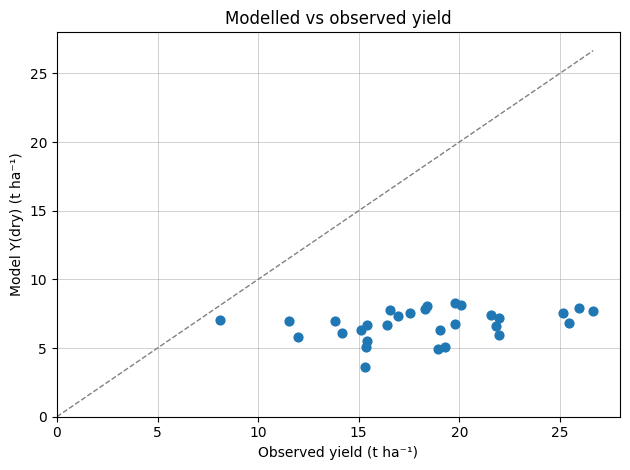

In [19]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "biomass", "A", "N3"))
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass", "Biomass")

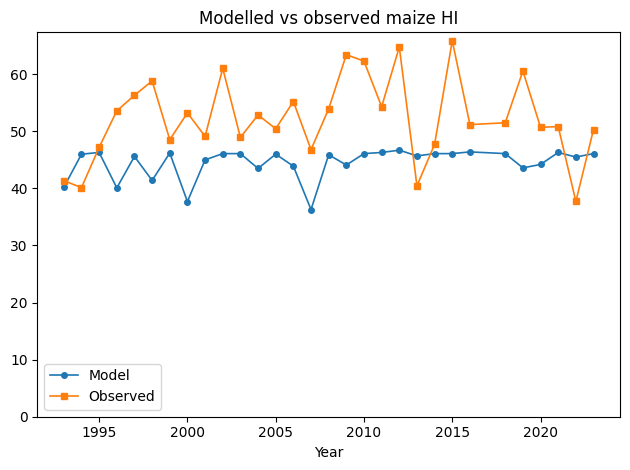

In [20]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI")

In [21]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(1.20),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,435.3,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,434.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,434.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,433.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,433.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,27,12,1993,-9,0,447.6,6.0,0.0,0.0,5.6,...,None,None,None,None,None,None,None,None,None,None
361,28,12,1993,-9,0,441.6,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
362,29,12,1993,-9,0,437.8,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
363,30,12,1993,-9,0,436.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

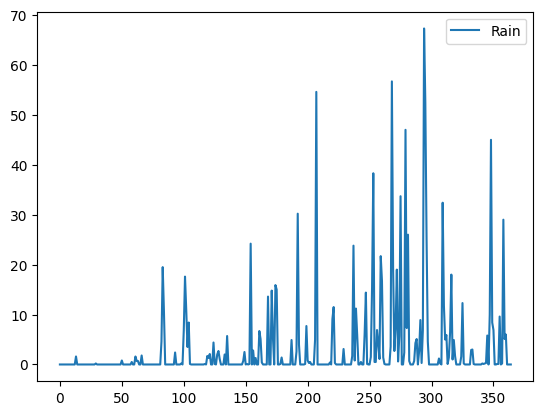

In [22]:
results["day"].plot(y="Rain")

<Axes: >

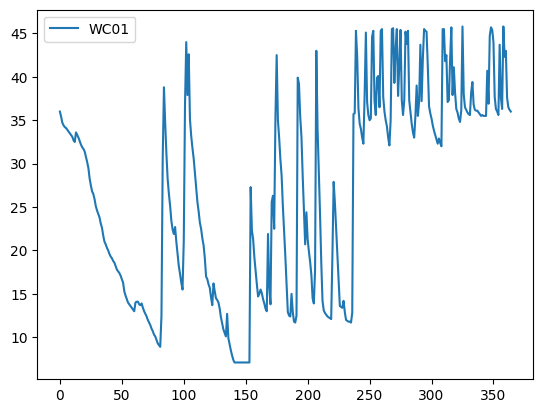

In [23]:
results["day"].plot(y="WC01")

In [24]:
#results["day"].plot(y="WC(2.30)")

<Axes: >

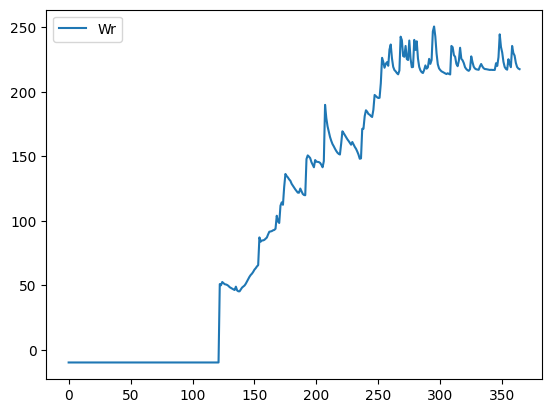

In [25]:
results["day"].plot(y="Wr")

<Axes: >

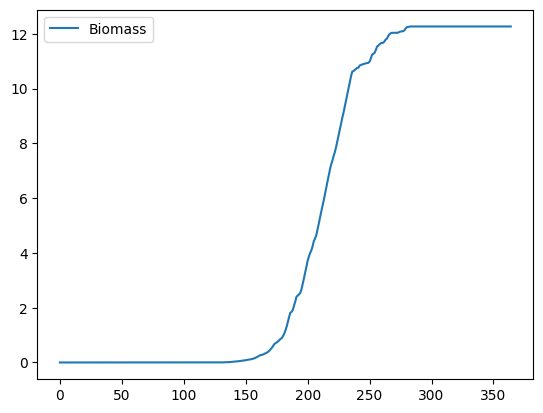

In [26]:
results["day"].plot(y="Biomass")

<Axes: >

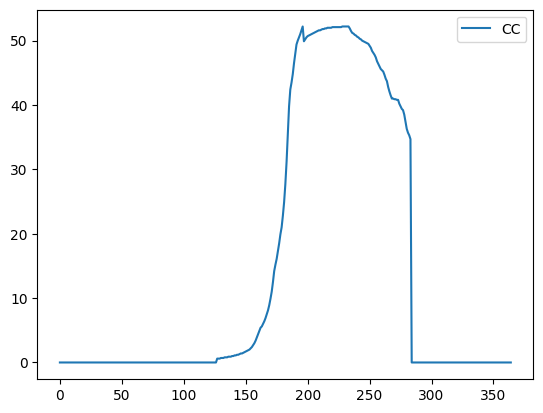

In [27]:
results["day"].plot(y="CC")

<Axes: >

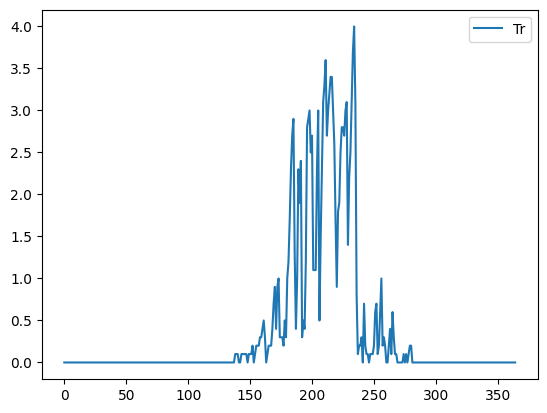

In [28]:
results["day"].plot(y="Tr")

<Axes: >

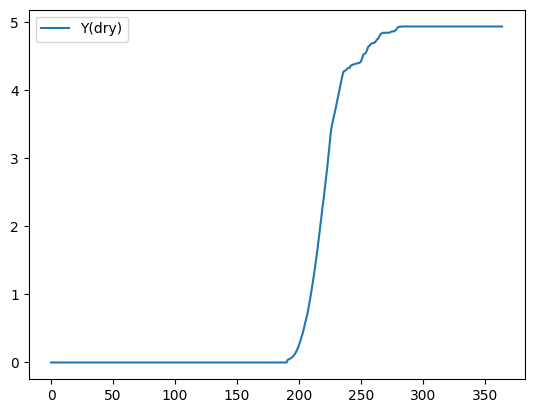

In [29]:
results["day"].plot(y="Y(dry)")

<Axes: >

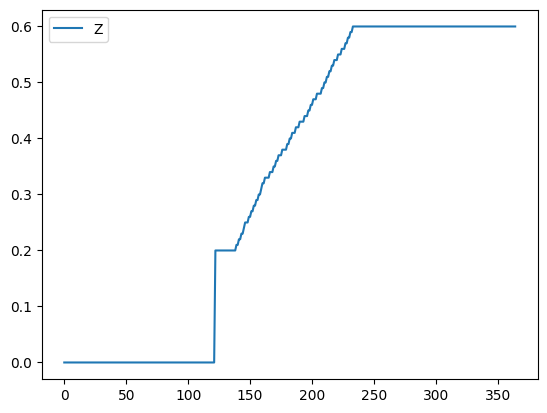

In [30]:
results["day"].plot(y="Z")

<Axes: >

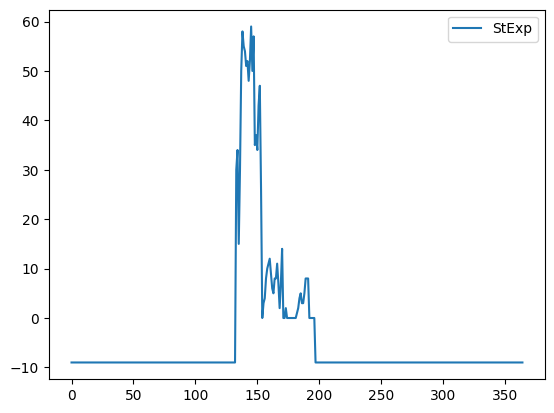

In [31]:
results["day"].plot(y="StExp")

<Axes: >

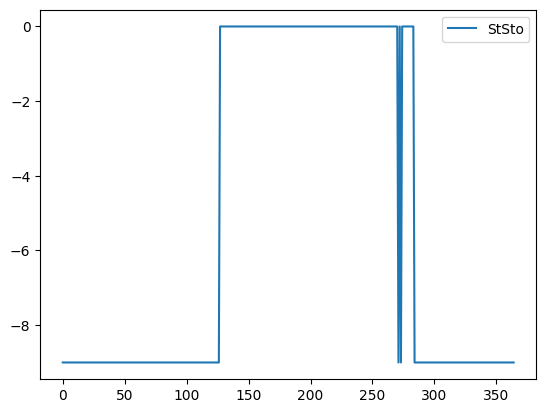

In [32]:
results["day"].plot(y="StSto")

<Axes: >

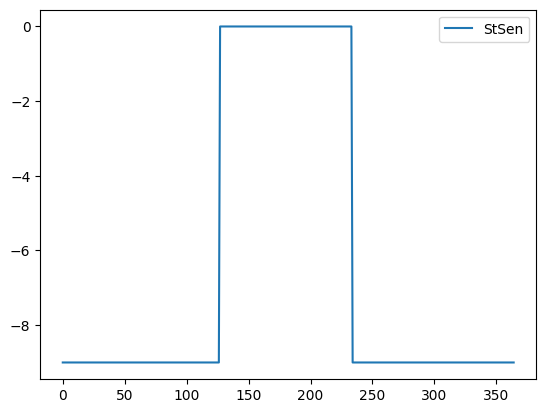

In [33]:
results["day"].plot(y="StSen")

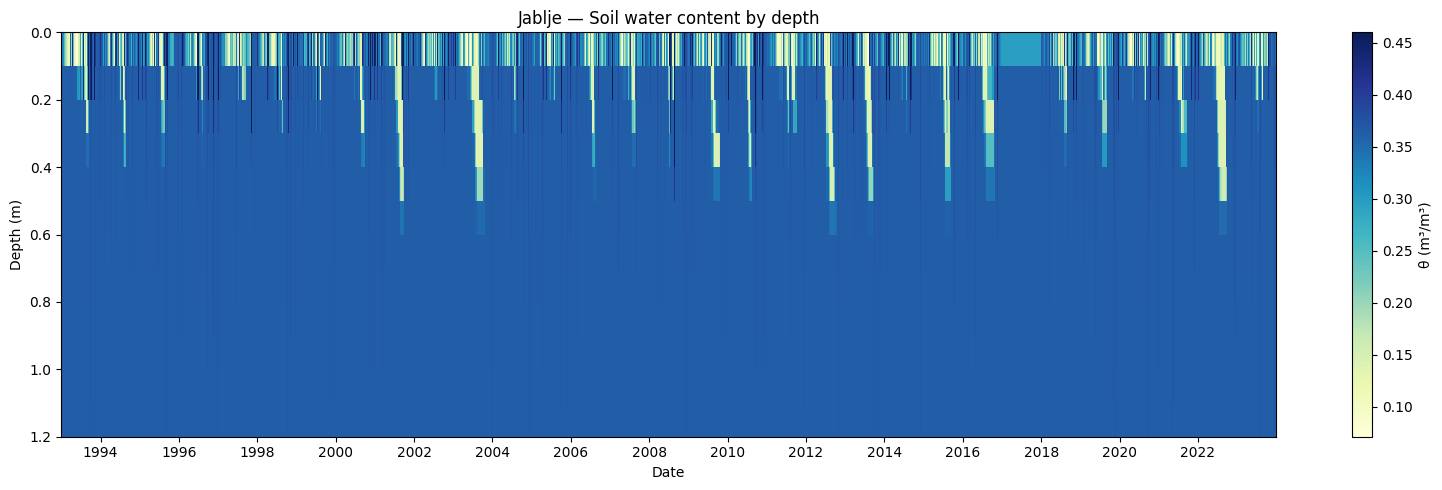

In [34]:
import pathlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from aquacrop.output import OutputReader

# Load daily output for all simulated years
reader = OutputReader(output_dir=str(output_dir / "OUTP"))
reader.scan_directory()

all_days = pd.concat(
    [reader.get_day_data(run_number=i) for i in range(1, len(simulation_periods) + 1)],
    ignore_index=True,
)
all_days.loc[:, "date"] = pd.to_datetime(dict(year=all_days["Year"], month=all_days["Month"], day=all_days["Day"]))

# AquaCrop writes "WC 2"–"WC 9" with spaces. The parser splits each into two tokens ("WC" + number),
# producing 8 extra column name slots. Data positions 69-80 (the 12 WC values) therefore land in
# alternating WC_N and bare-number columns. "WC_6"–"WC12" end up in the ECe section (all zeros).
wc_cols = ["WC01", "WC", "2", "WC_1", "3", "WC_2", "4", "WC_3", "5", "WC_4", "6", "WC_5"]

# Read compartment depth centres from the output file units row (line 5) at runtime.
# The units row lists depth [m] under each WC and ECe compartment; the first 12 numeric tokens
# are the WC compartment centres.
day_file = next(pathlib.Path(output_dir / "OUTP").glob("*day.OUT"))
with open(day_file) as f:
    units_line = f.readlines()[4]
numeric_units = []
for x in units_line.split():
    try:
        numeric_units.append(float(x))
    except ValueError:
        pass
centers = np.array(numeric_units[:12])

# Total soil depth from the WC(X.XX) column name
wc_total_col = next(c for c in all_days.columns if c.startswith("WC("))
total_depth = float(wc_total_col[3:-1])
bounds = np.concatenate([[0.0], (centers[:-1] + centers[1:]) / 2, [total_depth]])

# WC values are in vol%; convert to volumetric water content θ [m³/m³]
wc    = all_days[wc_cols].values.astype(float)   # (n_days, 12)
theta = wc / 100

# pcolormesh with shading='flat' needs (n+1) edges on both axes
dates   = mdates.date2num(all_days["date"].values)
x_edges = np.concatenate([[dates[0] - 0.5], dates + 0.5])

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.pcolormesh(x_edges, bounds, theta.T, cmap="YlGnBu", shading="flat")
ax.set_ylim(total_depth, 0)  # surface at top
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.colorbar(im, ax=ax, label="θ (m³/m³)")
ax.set_xlabel("Date")
ax.set_ylabel("Depth (m)")
ax.set_title("Jablje — Soil water content by depth")
plt.tight_layout()
plt.show()

In [35]:
theta

array([[0.36 , 0.363, 0.363, ..., 0.363, 0.363, 0.363],
       [0.354, 0.363, 0.363, ..., 0.363, 0.363, 0.363],
       [0.347, 0.363, 0.363, ..., 0.363, 0.363, 0.363],
       ...,
       [0.32 , 0.363, 0.363, ..., 0.363, 0.363, 0.363],
       [0.316, 0.363, 0.363, ..., 0.363, 0.363, 0.363],
       [0.312, 0.363, 0.363, ..., 0.363, 0.363, 0.363]], shape=(10957, 12))

<Axes: >

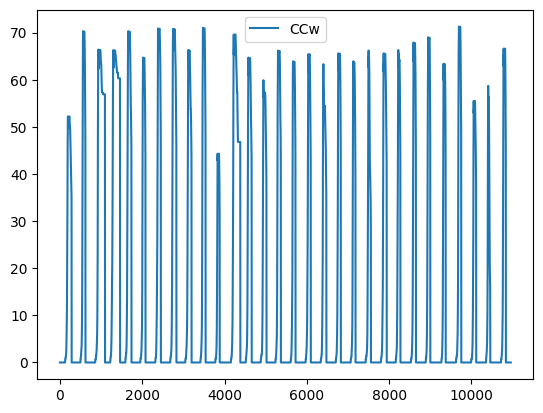

In [36]:
all_days.plot(y="CCw")